# Charged test particles in forced 3D RMHD turbulence

Boris-pushed test particles co-stepped with taranis's 3D RMHD solver
(`plans/TESTPART_PLAN.md` §11, phase B3). This is the 3D counterpart of
`test-particles-2D.ipynb`, and it exists for two reasons that 2D cannot serve.

1. **It is a direct literature check.** Xia, Perez, Chandran & Quataert (2013, ApJ 776, 90)
   measured stochastic ion heating in *3D* RMHD turbulence. The 2D campaign found
   $c_2 = 0.40\pm0.13$ (lab $v_\perp$, local-$\mathbf B$ $Q_\perp$, $2\sigma$ upper-limit
   rule) against their resolution-dependent $0.15$–$0.44$; whether that agreement survives
   in 3D, at a matched amplitude and under the same protocol, is the headline question.
2. **In 3D the parallel channel is unbounded.** In 2D $z$ is ignorable, so
   $p_z = v_z - (q/m)\psi$ is an *exact* invariant of the full-$\partial\psi/\partial t$
   dynamics and parallel energization is bounded by $(q/m)\Delta\psi$ — no secular parallel
   acceleration is possible even in principle. In 3D that argument fails: $\partial_z\ne0$,
   $E_z\ne-\partial_tA_z$, and $(v\times B)_z\ne-v\cdot\nabla A_z$. Headline 2 measures what
   the freed constraint actually buys, against a **matched 2D twin run** rather than against
   a remembered number.

**$B_0$ is pinned to 1 in 3D.** taranis writes RMHD in units where the guide field
(equivalently $v_A$) is exactly 1 — `rmhd.linear_matrix`'s off-diagonal is $ik_z$ — so the
cancellation $E_z = -B_0\partial_z\varphi + \partial_t\psi = -\{\varphi,\psi\}$ holds only at
$B_0 = 1$, and `Parameters` rejects anything else (`docs/numerics.md`, "$B_0$ in 3D"). The
per-ensemble amplitude knob that carried $\varepsilon = 1/B_0$ in 2D is therefore
**unavailable**: the RMHD amplitude parameter here is the run's own
$\varepsilon = u_{rms}/v_A = u_{rms}$, set by the forcing power, and it is measured below
rather than assumed. Two consequences run through everything that follows:

- an amplitude scan is a scan over *runs*, not over ensembles;
- $\beta_i = v_{\perp i}^2/v_A^2 = v_{\perp i}^2$ in code units, so the thermal speed sets
  $\beta_i$ **and** $\xi = \delta u(\rho)/v_\perp$ together. Xia et al. decoupled them by
  rescaling $v_A$ and $L_\parallel$ per cohort; that rescaling is exactly the per-ensemble
  $B_0$ the solver forbids here, so each ensemble's $(\xi,\beta_i)$ pair is locked.

Everything else follows the 2D protocol, which follows Xia et al.: the numerical
$E_\parallel$ left by interpolating $\mathbf E$ and $\mathbf B$ independently is projected out
per particle (`epar_project=True`, their eq. 21), heating is read in the **local-$\mathbf B$**
frame ($v_{\perp B}^2$, $v_{\parallel B}^2$), rate windows start at $t_0 = 10/\Omega$ and end
at $1.2\times$, and a rate that is not $2\sigma$ above zero is an **upper limit** held out of
every fit. Xia et al. report no error bars and no limit handling, so the fits below are also
quoted their way, with every point admitted.

Every heating claim is quoted against an in-situ **E = 0 control** ensemble (magnetic forces
do no work, so its kinetic-energy drift is the whole pipeline's numerical floor) and a
**$\delta b = 0$** pure-gyration control. Data is generated by
`examples/particles_3d_run.py` (resumable, idempotent), so this notebook runs from a fresh
clone with nothing bundled.

> **Profile.** The campaign size is a configuration choice, not an edit: set
> `TARANIS_P3D_PROFILE` to `smoke` (32²×16, minutes), `mvp` (128²×32) or `full` (256²×64,
> the production campaign) before running. **Under any profile but `full`, every number
> below is a pipeline check and not a physics result** — the interpretive cells say so where
> it matters.

In [1]:
import os
import time

import numpy as np
import matplotlib.pyplot as plt

import taranis as jr
import taranis.snapshot_io as sn
import taranis.diagnostics as diag
import taranis.diagnostics.particles as dpart
from taranis import grids
from taranis.particles import interp
from taranis.particles.fields import FIELD_PIECES, WORK_PIECES, assemble, particle_fields
from taranis.physics import shared_physics

import particles_3d_run as R

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "figure.facecolor": "white"})

PROFILE = R.PROFILE
C = R.cfg()
IS_PRODUCTION = PROFILE == "full"
print(f"profile {PROFILE!r}" + ("" if IS_PRODUCTION else
      "  <-- NOT the production profile: everything below is a pipeline check"))

field variables are using 64bit precision.
profile 'smoke'  <-- NOT the production profile: everything below is a pipeline check


In [2]:
dx, nu, t_eddy = R.geometry()
re = 0.2*R.LX/nu
print(f"fields    {C['nx']}^2 x {C['nz']}, Lx=Ly=2pi, Lz={R.ASPECT:g}*Lx, dx={dx:.5f}, "
      f"dims=3, finite-difference z, fp64, {R.SCHEME}, adaptive dt (cfl_safety=0.5)")
print(f"physics   RMHD, LAPLACIAN nu = eta = {nu:.3e} (hyper=1), Re = u_rms*Lx/nu = {re:.0f} "
      f"at the target u_rms = 0.2")
print(f"forcing   elsasser O-U, perp shell {R.FSHELL}, kz = +-2pi/Lz, tau={R.FORCING_TAU}; "
      f"target u_rms in {C['eps']}")
print(f"particles {C['npart']} per ensemble, substeps={C['substeps']}, B0 = 1 (pinned in 3D); "
      f"v_th = {C['vth']:g} -> beta_i = {2*C['vth']**2:.3f} for the maxwellian ensembles")
print(f"design (a): rho/dx in {R.RHO_DX_SWEEP} at fixed v_th, hosted at u_rms in {C['a_hosts']}")
print(f"design (b): rho/dx = {R.RHO_DX_REF:g} at each of u_rms in {C['eps']}")
print(f"design (c): rho/dx = {R.RHO_DX_C:g} fixed, rings at {R.VPERP_C_MUL} x v_perp,rms")
print(f"2D twins  : u_rms in {C['twins']} (B0 = 1/eps, same Omega, rho, xi, beta_i)")
ens_a, lab_a, _ = R.ensembles("a")
print(f"\n{len(ens_a)} ensembles per design-(a) run, 1 per design-(b) run")
print(f"\nXia et al. 2013 for reference: L_par/L_perp = 6, u_rms ~ v_A/5 (so chi ~ 1), "
      f"Laplacian dissipation at Re = 2400..38000, beta_i = 0.006..1, "
      f"delta_B_rms/B0 <= 0.47.")

fields    32^2 x 16, Lx=Ly=2pi, Lz=6*Lx, dx=0.19635, dims=3, finite-difference z, fp64, lsrk33, adaptive dt (cfl_safety=0.5)
physics   RMHD, LAPLACIAN nu = eta = 3.351e-03 (hyper=1), Re = u_rms*Lx/nu = 375 at the target u_rms = 0.2
forcing   elsasser O-U, perp shell (1, 3), kz = +-2pi/Lz, tau=1.0; target u_rms in (0.2, 0.3)
particles 256 per ensemble, substeps=1, B0 = 1 (pinned in 3D); v_th = 0.3 -> beta_i = 0.180 for the maxwellian ensembles
design (a): rho/dx in (2.0, 3.0, 4.0, 6.0, 8.0) at fixed v_th, hosted at u_rms in (0.3,)
design (b): rho/dx = 4 at each of u_rms in (0.2, 0.3)
design (c): rho/dx = 3 fixed, rings at (0.5, 1.0, 2.0, 4.0) x v_perp,rms
2D twins  : u_rms in (0.3,) (B0 = 1/eps, same Omega, rho, xi, beta_i)

13 ensembles per design-(a) run, 1 per design-(b) run

Xia et al. 2013 for reference: L_par/L_perp = 6, u_rms ~ v_A/5 (so chi ~ 1), Laplacian dissipation at Re = 2400..38000, beta_i = 0.006..1, delta_B_rms/B0 <= 0.47.


## Generating the data

`make_data` runs, in order, the particle-free 3D spin-ups (one per forcing power), the
particle runs restarted from each spin-up's last snapshot into its own directory, the matched
2D twins, the optional `hyper=3` twin and a short high-cadence tail. A particle run cannot
share a directory with a particle-free one, because `params.json` records `particles` and
`params.save` refuses a differing record. It is wall-clock bounded and resumes from whatever
is already on disk, so the loop below is safe to interrupt and re-run.

In [3]:
t0 = time.time()
while not R.make_data(wall_budget=1800.0):
    print(f"--- {time.time()-t0:.0f}s elapsed, continuing")
print(f"data ready ({time.time()-t0:.0f}s in this session)")

3D base spin-up, eps = 0.2
  data/test-particles-3D/base_eps0.2: already at t = 48.19 >= 47.12 (8 snapshots)
3D base spin-up, eps = 0.3
  data/test-particles-3D/base_eps0.3: already at t = 31.58 >= 31.42 (8 snapshots)
3D particles, design (a), eps = 0.3, 13 ensembles x 256
  data/test-particles-3D/design_a_eps0.3: already at t = 63.06 >= 62.83 (7 snapshots)
3D particles, design (b), eps = 0.2, 1 ensembles x 256
  data/test-particles-3D/design_b_eps0.2: already at t = 95.71 >= 94.25 (7 snapshots)
3D particles, design (b), eps = 0.3, 1 ensembles x 256
  data/test-particles-3D/design_b_eps0.3: already at t = 63.06 >= 62.83 (7 snapshots)
2D twin spin-up, eps = 0.3 (B0 = 3.33333)
  data/test-particles-3D/twin2d_base_eps0.3: already at t = 9.58 >= 9.42 (7 snapshots)
2D twin particles, eps = 0.3, 13 ensembles x 256
  data/test-particles-3D/twin2d_eps0.3: already at t = 18.86 >= 18.85 (7 snapshots)
high-cadence tail of design (a) eps = 0.3 (to t = 63.47)
  data/test-particles-3D/design_a_fast_

In [4]:
dirs = R.run_dirs()
def _du(p):
    if not os.path.isdir(p):
        return 0
    return sum(os.path.getsize(os.path.join(r, f)) for r, _d, fs in os.walk(p) for f in fs)
rows = [("3D base eps=%g" % e, dirs["base"][e]) for e in C["eps"]]
rows += [("3D design (a) eps=%g" % e, dirs["a"][e]) for e in C["a_hosts"]]
rows += [("3D design (b) eps=%g" % e, dirs["b"][e]) for e in C["eps"]]
rows += [("2D twin eps=%g" % e, dirs["twin2d"][e]) for e in C["twins"]]
rows += [("2D twin base eps=%g" % e, dirs["twin2d_base"][e]) for e in C["twins"]]
if "h3" in dirs:
    rows += [("3D hyper=3 twin", dirs["h3"][C["show"]]),
             ("3D hyper=3 base", dirs["base_h3"][C["show"]])]
rows += [("high-cadence tail", dirs["fast"])]
total = 0
for name, p in rows:
    total += _du(p)
    print(f"{name:26s} {len(sn.get_saved_steps(p)):3d} snapshots  {_du(p)/2**20:8.1f} MiB  {p}")
print(f"{'total':26s} {total/2**20:.0f} MiB on disk")

3D base eps=0.2              8 snapshots       0.7 MiB  data/test-particles-3D/base_eps0.2
3D base eps=0.3              8 snapshots       0.7 MiB  data/test-particles-3D/base_eps0.3
3D design (a) eps=0.3        7 snapshots       3.3 MiB  data/test-particles-3D/design_a_eps0.3
3D design (b) eps=0.2        7 snapshots       0.9 MiB  data/test-particles-3D/design_b_eps0.2
3D design (b) eps=0.3        7 snapshots       0.9 MiB  data/test-particles-3D/design_b_eps0.3
2D twin eps=0.3              7 snapshots       2.6 MiB  data/test-particles-3D/twin2d_eps0.3
2D twin base eps=0.3         7 snapshots       0.1 MiB  data/test-particles-3D/twin2d_base_eps0.3
high-cadence tail            3 snapshots       0.9 MiB  data/test-particles-3D/design_a_fast_eps0.3
total                      10 MiB on disk


## The base turbulence, and the amplitude it actually reached

Every run is spun up from rest with no particles and then continued with the ensembles
aboard. Because $B_0 \equiv 1$, the RMHD ordering parameter is a *property of this run*:
$\varepsilon = u_{rms}/v_A = u_{rms}$ and $\delta B/B_0 = b_{rms}$. The three numbers that say
whether the run means anything are printed below and none of them is assumed:

- $\varepsilon = u_{rms}$ against the target the forcing power was chosen for;
- $\delta B_{rms}/B_0 = b_{rms}$ against Xia et al.'s $\le0.47$ cap (they flag even that);
- $\chi = \omega_{nl}/\omega_A = (k_\perp u_{rms})/(k_z v_A)$ at the forced scale — the
  critical-balance parameter. Xia et al. drive at $\chi\simeq1$ with $L_\parallel/L_\perp = 6$
  and $u_{rms}\simeq v_A/5$; this notebook holds $L_z$ fixed across the forcing ladder, so
  $\chi$ moves with $\varepsilon$ and the weak hosts are *not* critically balanced. That is
  the price of a fixed box, and it is reported per host.

In [5]:
_states = {}
def load_state(path, i, params):
    key = (path, i)
    if key not in _states:
        _states[key] = sn.load_snapshot(i, path, params)
    return _states[key]

def snap_index(path, params):
    '''(steps, times) at the UNIQUE snapshot times of `path`, in time order. A resumed
    make_data call re-saves the state it restarted from, so the raw step list can hold
    repeated times; a repeated time would give a zero-dt snapshot pair below.'''
    by_t = {}
    for i in sn.get_saved_steps(path):
        by_t[float(load_state(path, i, params).t)] = i
    ts = np.array(sorted(by_t))
    return [by_t[t] for t in ts], ts

_ener = {}
def energies(path, params, kgrid, steps):
    key = (path, tuple(steps))
    if key in _ener:
        return _ener[key]
    ek, em = [], []
    for i in steps:
        s = load_state(path, i, params)
        ek.append(float(0.5*shared_physics.perp_inner_product(s.fields[0], s.fields[0],
                                                              kgrid, params)))
        em.append(float(0.5*shared_physics.perp_inner_product(s.fields[1], s.fields[1],
                                                              kgrid, params)))
    _ener[key] = (np.array(ek), np.array(em))
    return _ener[key]

EPS_SHOW = C["show"]
params_a, path_a, labels_a, idx_a = R.particle_run("a", EPS_SHOW)
kgrid = jr.setup_kgrids(params_a)
base_params = R.make_params(EPS_SHOW)
base_dir = dirs["base"][EPS_SHOW]

bsteps, bts = snap_index(base_dir, base_params)
asteps, ats = snap_index(path_a, params_a)
bek, bem = energies(base_dir, base_params, kgrid, bsteps)
aek, aem = energies(path_a, params_a, kgrid, asteps)
print(f"base spin-up: {len(bsteps)} snapshots to t={bts[-1]:.2f}; "
      f"particle run: {len(asteps)} snapshots, t={ats[0]:.2f}..{ats[-1]:.2f}")

base spin-up: 7 snapshots to t=31.58; particle run: 6 snapshots, t=31.58..63.06


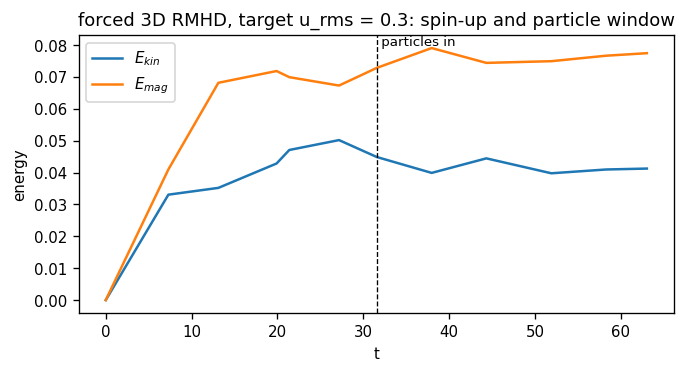

    host    u_rms    b_rms  eps=u_rms    dB/B0     chi   T_eddy   (target eps in the first column)
     0.2    0.188    0.233      0.188    0.233    1.13     33.5
     0.3    0.289    0.390      0.289    0.390    1.74     21.7

forcing calibration: P = 3.4*u_target^3/Lx reached u_rms/u_target = 0.94, 0.96 -- retune particles_3d_run.FORCE_C by the cube of the miss if these are far from 1.
ordering check at the shown host: delta_B/B0 = 0.390 against Xia et al.'s <= 0.47 cap (inside)


In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(np.r_[bts, ats], np.r_[bek, aek], label=r"$E_{kin}$")
ax.plot(np.r_[bts, ats], np.r_[bem, aem], label=r"$E_{mag}$")
ax.axvline(ats[0], color="k", ls="--", lw=0.8)
ax.text(ats[0], ax.get_ylim()[1], " particles in", va="top", fontsize=8)
ax.set_xlabel("t"); ax.set_ylabel("energy")
ax.set_title(f"forced 3D RMHD, target u_rms = {EPS_SHOW:g}: spin-up and particle window")
ax.legend()
plt.show()

kperp1 = 2*np.pi/R.LX
kz1 = 2*np.pi/R.LZ
print(f"{'host':>8} {'u_rms':>8} {'b_rms':>8} {'eps=u_rms':>10} {'dB/B0':>8} {'chi':>7} "
      f"{'T_eddy':>8}   (target eps in the first column)")
achieved = {}
for eps in C["eps"]:
    prm, pth, _lb, _ix = R.particle_run("a" if eps in C["a_hosts"] else "b", eps)
    st, tt = snap_index(pth, prm)
    ek, em = energies(pth, prm, kgrid if eps == EPS_SHOW else jr.setup_kgrids(prm), st)
    u, b = float(np.sqrt(2*ek.mean())), float(np.sqrt(2*em.mean()))
    achieved[eps] = (u, b)
    print(f"{eps:8g} {u:8.3f} {b:8.3f} {u:10.3f} {b:8.3f} {kperp1*u/(kz1*1.0):7.2f} "
          f"{R.LX/max(u, 1e-9):8.1f}")
u_show, b_show = achieved[EPS_SHOW]
print(f"\nforcing calibration: P = {R.FORCE_C:g}*u_target^3/Lx reached u_rms/u_target = "
      + ", ".join(f"{achieved[e][0]/e:.2f}" for e in C["eps"])
      + f" -- retune particles_3d_run.FORCE_C by the cube of the miss if these are far from 1.")
print(f"ordering check at the shown host: delta_B/B0 = {b_show:.3f} against Xia et al.'s "
      f"<= 0.47 cap ({'inside' if b_show <= 0.47 else 'OUTSIDE -- the RMHD ordering is violated'})")

### Time-averaged spectra, the resolution check, and the anisotropy

$E_u(k_\perp)$ and $E_b(k_\perp)$ averaged over the particle window's snapshots.
$\delta u(\rho)$ — the velocity at the gyroradius, which sets $\xi$ — is read off this curve
at $k=1/\rho$ with the convention $\langle u^2\rangle = 2\int E_u\,dk$, i.e.
$\delta u(k) = \sqrt{2kE_u(k)}$ (`diagnostics.particles.delta_u`).

Xia et al. define $\delta u$ differently: $\delta u^2 = \int_{k_-}^{k_+}E_u\,dk$ with
$k_\pm = e^{\pm1/2}/\rho$, a band one $e$-fold wide centred on $k_\rho$. For a locally
power-law spectrum the two differ by only a few percent; the third panel measures the ratio
on *this* spectrum rather than assuming it, and the fits below are repeated with the band
version in the sensitivity table.

The parallel spectrum (`parspec`, single-rank only, which every particle run is) is the 3D
diagnostic 2D has no analogue for: it says whether $n_z$ resolves the critically-balanced
parallel structure at the perpendicular scales the particles sample.

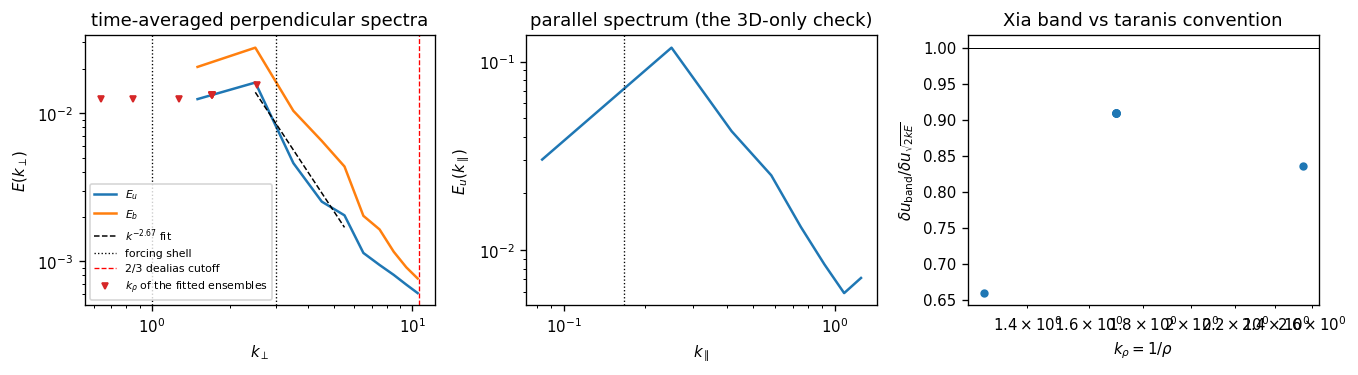

E_u peaks at k = 2.5; power law over k in [2, 6.4]: E_u ~ k^-2.67  => delta_u ~ rho^+0.83
fitted ensembles sample k_rho in [0.6, 2.5], i.e. rho/dx in [2.0, 8.0] AT INSERTION
delta_u convention: Xia's e-fold band integral / taranis's sqrt(2 k E_u) = 0.659..0.909 over the fitted gyroradii
parallel resolution: kz grid runs to 1.25 = 8 x the box mode; the perpendicular grid runs to 11 = 11 x. Critical balance wants kz/kperp ~ eps*(kperp)^(-1/3) at the particle scales, i.e. kz ~ 0.54 at the smallest gyroradius.


In [7]:
_spec = {}
def mean_spectrum(path, params, kgrid, steps):
    key = (path, tuple(steps))
    if key in _spec:
        return _spec[key]
    ku = eu = eb = None
    for i in steps:
        s = load_state(path, i, params)
        # kinetic_spectrum defaults to bin_factor=1.0, perpspec to 2.0 -- pin both
        k, su = dpart.kinetic_spectrum(s, kgrid, params, bin_factor=1.0)
        _k, _su, sb = diag.perpspec(s, kgrid, params, bin_factor=1.0)
        ku = k if ku is None else ku
        eu = su if eu is None else eu + su
        eb = np.asarray(sb) if eb is None else eb + np.asarray(sb)
    _spec[key] = (ku, eu/len(steps), eb/len(steps))
    return _spec[key]

def delta_u_band(k, Ekin, rho):
    '''Xia et al. eq. 6: delta_u^2 = integral of E_u over one e-fold centred on k = 1/rho,
    with E_u = 2*Ekin (taranis's kinetic_spectrum normalizes to <u^2> = 2*int Ekin dk).'''
    k = np.asarray(k, float); g = 2.0*np.asarray(Ekin, float)
    good = (k > 0) & np.isfinite(g)
    k, g = k[good], g[good]
    lo, hi = np.exp(-0.5)/rho, np.exp(0.5)/rho
    kk = np.unique(np.clip(np.r_[k, lo, hi], k.min(), k.max()))
    gg = np.interp(kk, k, g)
    sel = (kk >= lo) & (kk <= hi)
    return float(np.sqrt(np.trapezoid(gg[sel], kk[sel]))) if sel.sum() > 1 else np.nan

def omega_of(ens):
    return abs(dpart.gyrofrequency(ens["qm"], ens["B0"]))

def vperp0(ens):
    init = ens["init"]
    return np.sqrt(2.0)*init["vth"] if init["kind"] == "maxwellian" else init["vperp"]

k_a, Eu_a, Eb_a = mean_spectrum(path_a, params_a, kgrid, asteps)
fit_idx = list(idx_a["sweep"]) + list(idx_a["rings"])
rho_a = np.array([float(dpart.gyroradius(vperp0(e), e["qm"], e["B0"]))
                  for e in params_a.particles["ensembles"]])
good = (k_a > 0) & (Eu_a > 0)
kk, uu = k_a[good], Eu_a[good]
kcut = (2.0/3.0)*(C["nx"]//2)*(2*np.pi/R.LX)

K0, K1 = 2.0, min(20.0, 0.6*kcut)
band = (kk >= K0) & (kk <= K1)
pl = np.polyfit(np.log(kk[band]), np.log(uu[band]), 1) if band.sum() > 2 else np.array([np.nan, np.nan])

kzs, Euz, Ebz = None, None, None
for i in asteps:
    kz, su, sb = diag.parspec(load_state(path_a, i, params_a), kgrid, params_a,
                              bin_factor=1.0)
    kzs = np.asarray(kz) if kzs is None else kzs
    Euz = np.asarray(su) if Euz is None else Euz + np.asarray(su)
Euz = Euz/len(asteps)

fig, ax = plt.subplots(1, 3, figsize=(11.4, 3.2))
ax[0].loglog(kk, uu, label=r"$E_u$")
ax[0].loglog(k_a[good], np.maximum(Eb_a[good], 1e-300), label=r"$E_b$")
if np.isfinite(pl[0]):
    ax[0].loglog(kk[band], np.exp(np.polyval(pl, np.log(kk[band]))), "k--", lw=0.9,
                 label=r"$k^{%.2f}$ fit" % pl[0])
for j, kf in enumerate(R.FSHELL):
    ax[0].axvline(kf, color="k", ls=":", lw=0.8, label="forcing shell" if j == 0 else None)
ax[0].axvline(kcut, color="r", ls="--", lw=0.8, label="2/3 dealias cutoff")
for j, e in enumerate(fit_idx):
    ax[0].plot([1.0/rho_a[e]], [np.interp(1.0/rho_a[e], kk, uu)], "v", ms=4, color="C3",
               label=r"$k_\rho$ of the fitted ensembles" if j == 0 else None)
ax[0].set_xlabel(r"$k_\perp$"); ax[0].set_ylabel(r"$E(k_\perp)$")
ax[0].legend(fontsize=6.5); ax[0].set_title("time-averaged perpendicular spectra")

gz = kzs > 0
ax[1].loglog(kzs[gz], np.maximum(Euz[gz], 1e-300))
ax[1].axvline(2*np.pi/R.LZ, color="k", ls=":", lw=0.8)
ax[1].set_xlabel(r"$k_\parallel$"); ax[1].set_ylabel(r"$E_u(k_\parallel)$")
ax[1].set_title("parallel spectrum (the 3D-only check)")

rr = np.array([rho_a[e] for e in fit_idx])
ratio = np.array([delta_u_band(kk, uu, r)/dpart.delta_u(kk, uu, r) for r in rr])
ax[2].semilogx(1.0/rr, ratio, "o", ms=4)
ax[2].axhline(1.0, color="k", lw=0.6)
ax[2].set_xlabel(r"$k_\rho = 1/\rho$")
ax[2].set_ylabel(r"$\delta u_{\rm band}/\delta u_{\sqrt{2kE}}$")
ax[2].set_title("Xia band vs taranis convention")
plt.tight_layout(); plt.show()

print(f"E_u peaks at k = {kk[np.argmax(uu)]:.1f}; power law over k in [{K0:g}, {K1:g}]: "
      f"E_u ~ k^{pl[0]:.2f}  => delta_u ~ rho^{-0.5*(1+pl[0]):+.2f}")
print(f"fitted ensembles sample k_rho in [{min(1/rho_a[fit_idx]):.1f}, "
      f"{max(1/rho_a[fit_idx]):.1f}], i.e. rho/dx in "
      f"[{min(rho_a[fit_idx])/dx:.1f}, {max(rho_a[fit_idx])/dx:.1f}] AT INSERTION")
print(f"delta_u convention: Xia's e-fold band integral / taranis's sqrt(2 k E_u) = "
      f"{np.nanmin(ratio):.3f}..{np.nanmax(ratio):.3f} over the fitted gyroradii")
print(f"parallel resolution: kz grid runs to {kzs.max():.2f} = "
      f"{kzs.max()/(2*np.pi/R.LZ):.0f} x the box mode; the perpendicular grid runs to "
      f"{kcut:.0f} = {kcut/(2*np.pi/R.LX):.0f} x. Critical balance wants "
      f"kz/kperp ~ eps*(kperp)^(-1/3) at the particle scales, i.e. "
      f"kz ~ {u_show*max(1/rho_a[fit_idx])**(2/3):.2f} at the smallest gyroradius.")

## The ensembles

`n` in `params.particles` is the count **per ensemble**. Every ensemble carries a static mask
over the five field pieces `(bperp, eperp, ez_ideal, ez_resistive, ez_forcing)` — the default
is the ideal-Ohm particle — plus its `epar_project` flag; `B0` is 1 for all of them, in 3D by
force. $\rho/dx\ge2$ is the floor trilinear interpolation needs, $\Omega\,dt/\mathrm{substeps}$
is the gyration resolution at the run's adaptive timestep, and $\beta_i = v_\perp^2$ is
whatever the thermal speed makes it.

In [8]:
mom_a = dpart.read_moments(path_a)
dt_a = float(np.median(np.diff(mom_a["t"])))
sub = params_a.particles["substeps"]
print(f"{'#':>2}  {'label':<34} {'Omega':>7} {'q/m':>7} {'beta_i':>7} {'init':<20} "
      f"{'rho/dx':>7} {'steps/gyr':>10} {'proj':>5}  mask")
for e, ens in enumerate(params_a.particles["ensembles"]):
    init = ens["init"]
    ini = (f"maxwellian vth={init['vth']:.3g}" if init["kind"] == "maxwellian"
           else f"ring v_perp={init['vperp']:.3g}")
    on = ",".join(p for p in FIELD_PIECES if ens["mask"][p]) or "none (B0 zhat only)"
    om = omega_of(ens)
    print(f"{e:>2}  {labels_a[e]:<34} {om:7.2f} {ens['qm']:7.3f} {vperp0(ens)**2:7.3f} "
          f"{ini:<20} {rho_a[e]/dx:7.2f} {2*np.pi/(om*dt_a/sub):10.0f} "
          f"{str(ens['epar_project']):>5}  {on}")
print(f"\nmedian solver dt over the particle run = {dt_a:.2e}, substeps = {sub}")
print(f"beta_i spans {min(vperp0(e)**2 for e in params_a.particles['ensembles']):.3f}"
      f"..{max(vperp0(e)**2 for e in params_a.particles['ensembles']):.3f} against Xia et "
      f"al.'s 0.006..1 -- and it is NOT independent of xi here (B0 is pinned), which is the "
      f"one design freedom 3D loses relative to the 2D campaign.")

 #  label                                Omega     q/m  beta_i init                  rho/dx  steps/gyr  proj  mask
 0  (a) rho/dx = 2, Omega = 1.08          1.08   1.080   0.180 maxwellian vth=0.3      2.00         92  True  bperp,eperp,ez_ideal
 1  (a) rho/dx = 3, Omega = 0.72          0.72   0.720   0.180 maxwellian vth=0.3      3.00        138  True  bperp,eperp,ez_ideal
 2  (a) rho/dx = 4, Omega = 0.54          0.54   0.540   0.180 maxwellian vth=0.3      4.00        185  True  bperp,eperp,ez_ideal
 3  (a) rho/dx = 6, Omega = 0.36          0.36   0.360   0.180 maxwellian vth=0.3      6.00        277  True  bperp,eperp,ez_ideal
 4  (a) rho/dx = 8, Omega = 0.27          0.27   0.270   0.180 maxwellian vth=0.3      8.00        369  True  bperp,eperp,ez_ideal
 5  (c) ring v_perp = 0.5 v_th_rms        0.36   0.360   0.045 ring v_perp=0.212       3.00        277  True  bperp,eperp,ez_ideal
 6  (c) ring v_perp = 1 v_th_rms          0.72   0.720   0.180 ring v_perp=0.424       3.00        

## Energy bookkeeping

`ParticleState.w` accumulates the work per unit mass done by each electric piece, credited
inside the pusher from the exact Boris half-kick identity
$\Delta(\tfrac12|v|^2) = h\,\mathbf{E}\cdot(\mathbf{v}_{in}+\mathbf{v}_{new})$. Summing the
pieces must reproduce the kinetic-energy change to round-off — the `closure` column — which is
what makes the heating *attribution* a measurement rather than an inference. A piece an
ensemble's mask omits stays exactly zero.

In [9]:
p_first = sn.load_particles(asteps[0], path_a, params_a)
p_last = sn.load_particles(asteps[-1], path_a, params_a)
bud = dpart.energy_budget(p_last, p_first)
ke0 = float(np.mean(0.5*np.sum(np.asarray(p_first.v)**2, axis=2)))

hdr = "  ".join(f"{p:>12}" for p in WORK_PIECES)
print(f"work per unit mass over t = {ats[0]:.1f} -> {ats[-1]:.1f} "
      f"(initial <KE> per unit mass = {ke0:.4f})\n")
print(f"{'#':>2}  {'ensemble':<34} {'d<KE>':>10}  {hdr}  {'total':>10}  {'closure/d<KE>':>13}")
for e in range(len(labels_a)):
    w = "  ".join(f"{v:12.3e}" for v in bud["work"][e])
    rel = ("n/a (0/0)" if bud["total_work"][e] == 0.0
           else f"{bud['closure'][e]/bud['dke'][e]:.2e}")
    print(f"{e:>2}  {labels_a[e]:<34} {bud['dke'][e]:10.3e}  {w}  "
          f"{bud['total_work'][e]:10.3e}  {rel:>13}")
works = bud["total_work"] != 0.0
print(f"\nlargest |closure| over the {int(works.sum())} ensembles that do work: "
      f"{np.max(np.abs(bud['closure'][works])):.2e} "
      f"({np.max(np.abs(bud['closure'][works]))/ke0:.1e} of the initial KE)")

v0 = np.asarray(p_first.v); v1 = np.asarray(p_last.v)
rel = np.abs(np.sum(v1**2, axis=2)/np.sum(v0**2, axis=2) - 1.0)
for name, e in (("E = 0 control", idx_a["e_zero"]),
                ("delta-b = 0 control", idx_a["gyration"])):
    print(f"{name:22s}: max per-particle |v|^2 drift {rel[e].max():.2e}, "
          f"mean {rel[e].mean():.2e}; w exactly zero: "
          f"{bool(np.all(np.asarray(p_last.w[e]) == 0.0))}")
for name, e in (("ideal reference", idx_a["ideal_ref"]), ("full dpsi/dt", idx_a["full"])):
    print(f"{name:22s}: mean per-particle |v|^2 change {rel[e].mean():.4f}")
print("\nthe E = 0 ensemble's drift is the numerical-heating FLOOR every rate below is "
      "quoted against. A run whose smallest measured heating is not far above it has "
      "measured its own arithmetic.")

work per unit mass over t = 31.6 -> 63.1 (initial <KE> per unit mass = 0.2373)

 #  ensemble                                d<KE>         eperp      ez_ideal  ez_resistive    ez_forcing       total  closure/d<KE>
 0  (a) rho/dx = 2, Omega = 1.08        2.308e-01     2.198e-01     1.099e-02     0.000e+00     0.000e+00   2.308e-01       1.44e-15
 1  (a) rho/dx = 3, Omega = 0.72        1.923e-01     1.785e-01     1.378e-02     0.000e+00     0.000e+00   1.923e-01      -1.01e-15
 2  (a) rho/dx = 4, Omega = 0.54        1.437e-01     1.333e-01     1.043e-02     0.000e+00     0.000e+00   1.437e-01       7.72e-16
 3  (a) rho/dx = 6, Omega = 0.36        8.735e-02     8.536e-02     1.995e-03     0.000e+00     0.000e+00   8.735e-02       6.35e-16
 4  (a) rho/dx = 8, Omega = 0.27        7.588e-02     7.480e-02     1.083e-03     0.000e+00     0.000e+00   7.588e-02       9.14e-16
 5  (c) ring v_perp = 0.5 v_th_rms      1.341e-01     1.286e-01     5.553e-03     0.000e+00     0.000e+00   1.341e-01     

## Magnetic moment

$\mu = v_{\perp B}^2/2|B|$ about the **local** field, tracked two ways: the per-step sidecar
column (the pusher's own last $B$ sample, no extra gather) and, at snapshot cadence,
`mu_of`. $D_\mu$ is quoted both as $\tfrac12\,d\,\mathrm{Var}(\mu)/dt$ from the sidecar and as
the snapshot-pair estimator $\tfrac12\langle(\Delta\mu)^2\rangle/\Delta t$; the 2D campaign
found the pair estimator 9–41× larger because it counts reversible $\mu$ oscillation as
diffusion, and the E = 0 control (whose $\mu$ cannot diffuse at all) is the demonstration.

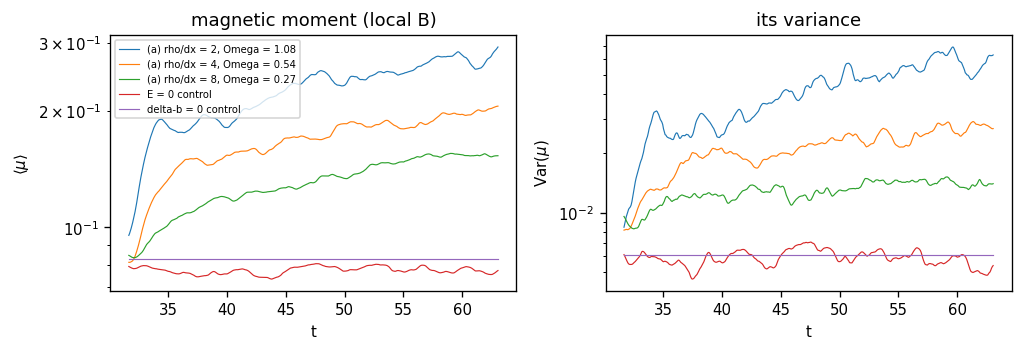

 #  ensemble                             <mu> end   D_mu (sidecar)   D_mu (pairs)
 0  (a) rho/dx = 2, Omega = 1.08           0.2924   7.15e-04+-4e-04       3.25e-03
 1  (a) rho/dx = 3, Omega = 0.72           0.2352   3.79e-04+-2e-04       2.24e-03
 2  (a) rho/dx = 4, Omega = 0.54           0.2057   2.00e-04+-1e-04       1.54e-03
 3  (a) rho/dx = 6, Omega = 0.36           0.1642   8.25e-05+-6e-05       7.46e-04
 4  (a) rho/dx = 8, Omega = 0.27           0.1532   5.06e-05+-3e-05       5.10e-04
 5  (c) ring v_perp = 0.5 v_th_rms         0.1311   1.97e-04+-2e-05       4.55e-04
 6  (c) ring v_perp = 1 v_th_rms           0.2312   3.32e-04+-1e-04       1.86e-03
 7  (c) ring v_perp = 2 v_th_rms           0.3969   7.76e-04+-3e-04       4.74e-03
 8  (c) ring v_perp = 4 v_th_rms           1.1159   1.50e-03+-8e-04       1.89e-02
 9  rho/dx = 4, unprojected                0.2181   2.16e-04+-1e-04       1.59e-03
10  rho/dx = 4, full dpsi/dt               0.2345   2.37e-04+-3e-05       1.60e-03
11  E

In [10]:
show = [idx_a["sweep"][0], idx_a["ideal_ref"], idx_a["sweep"][-1],
        idx_a["e_zero"], idx_a["gyration"]]
fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.0))
for e in show:
    ax[0].plot(mom_a["t"], mom_a["mu"][:, e], lw=0.7, label=labels_a[e])
    ax[1].plot(mom_a["t"], mom_a["mu2"][:, e] - mom_a["mu"][:, e]**2, lw=0.7)
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"$\langle\mu\rangle$"); ax[0].legend(fontsize=6)
ax[1].set_xlabel("t"); ax[1].set_ylabel(r"$\mathrm{Var}(\mu)$")
for a in ax:
    a.set_yscale("log")
ax[0].set_title("magnetic moment (local B)"); ax[1].set_title("its variance")
plt.tight_layout(); plt.show()

t_fit0 = ats[0] + 0.1*(ats[-1] - ats[0])
D, Derr = dpart.mu_diffusion(mom_a, t0=t_fit0)
mus = [dpart.mu_of(sn.load_particles(i, path_a, params_a), load_state(path_a, i, params_a),
                   kgrid, params_a) for i in asteps]
Dpair = np.mean([dpart.increment_diffusion(mus[j], mus[j+1], ats[j+1]-ats[j])
                 for j in range(len(asteps)-1)], axis=0)
print(f"{'#':>2}  {'ensemble':<34} {'<mu> end':>10} {'D_mu (sidecar)':>16} {'D_mu (pairs)':>14}")
for e in range(len(labels_a)):
    print(f"{e:>2}  {labels_a[e]:<34} {mom_a['mu'][-1, e]:10.4f} "
          f"{D[e]:10.2e}+-{Derr[e]:.0e} {Dpair[e]:14.2e}")
j = len(asteps)//2
row = int(np.argmin(np.abs(mom_a["t"] - ats[j])))
print(f"\nmu_of vs sidecar at t = {ats[j]:.3f} (nearest row t = {mom_a['t'][row]:.3f}): "
      f"max relative difference over the ensembles "
      f"{np.max(np.abs(mus[j].mean(axis=1)/mom_a['mu'][row] - 1.0)):.2e}")
ez = idx_a["e_zero"]
print(f"the E = 0 control, whose mu cannot diffuse: D_mu(sidecar) = {D[ez]:.2e} "
      f"+- {Derr[ez]:.0e} against D_mu(pairs) = {Dpair[ez]:.2e} -- read the pair column as "
      f"an upper bound at this cadence.")

# the high-cadence tail: the same pair estimator over a much shorter interval, where less of
# the reversible mu oscillation has had time to enter <(dmu)^2>
fsteps, fts = snap_index(dirs["fast"], params_a)
if len(fsteps) > 1:
    fmus = [dpart.mu_of(sn.load_particles(i, dirs["fast"], params_a),
                        load_state(dirs["fast"], i, params_a), kgrid, params_a)
            for i in fsteps]
    Dfast = np.mean([dpart.increment_diffusion(fmus[j], fmus[j+1], fts[j+1]-fts[j])
                     for j in range(len(fsteps)-1)], axis=0)
    dtf = float(np.mean(np.diff(fts)))
    print(f"\nhigh-cadence tail: {len(fsteps)} snapshots, interval {dtf:.4f} = "
          f"{dtf*omega_of(params_a.particles['ensembles'][idx_a['ideal_ref']])/(2*np.pi):.2f} "
          f"gyroperiods at the reference Omega (the production cadence is "
          f"{float(np.mean(np.diff(ats)))*omega_of(params_a.particles['ensembles'][idx_a['ideal_ref']])/(2*np.pi):.1f})")
    print(f"{'#':>2}  {'ensemble':<34} {'D_mu (fast pairs)':>18} {'/ sidecar':>10}")
    for e in range(len(labels_a)):
        print(f"{e:>2}  {labels_a[e]:<34} {Dfast[e]:18.3e} "
              f"{Dfast[e]/D[e] if D[e] != 0 else np.nan:10.2f}")
else:
    print("\nhigh-cadence tail: fewer than two snapshots, pair estimator skipped")

## Headline 1 — $Q_\perp(\xi)$, and how it compares with Xia et al.

Measurement protocol, identical to the 2D campaign's so the two are comparable, and following
Xia et al. (2013) §4.1:

- the perpendicular energy is the **local-$\mathbf B$** one, $\tfrac12\langle v_{\perp B}^2
  \rangle$ (sidecar column `vperpB2`, one row per solver step), smoothed with a 101-step
  running mean; the parallel one is `vparB2`;
- the window **starts** at $t_0 = 10/\Omega$ after insertion (skipping the
  $\mathbf E\times\mathbf B$ pickup) and **ends** at the first step where the smoothed
  $\langle v_{\perp B}^2\rangle$ exceeds $1.2\times$ its $t_0$ value, or at the run end,
  but never sooner than `NMIN` solver steps (the `ext` column flags where that floor bound
  it);
- $\rho = v_\perp/\Omega$ and $\xi = \delta u(\rho)/v_\perp$ use $v_\perp$ **at $t_0$**, and
  $\delta u(\rho)$ comes from the run's own kinetic spectrum averaged over the snapshots
  *inside* the window (`nsp` is that count; where it is zero the whole-run average is used).

**The exclusion rule.** A window whose $Q_\perp$ is not $2\sigma$ above zero is an **upper
limit**: starred in the tables, drawn as an arrow, and held out of every fit. Xia et al. quote
no error bars and no limit rule, so the sensitivity table also carries the row that admits
every point — that is the Xia-comparable fit, and in 2D the two differed by $0.2$ in $c_2$.

In [11]:
def _smooth(y, w):
    w = max(1, min(w | 1, (len(y)//4) | 1))
    pad = w//2
    return np.convolve(np.pad(y, pad, mode="edge"), np.ones(w)/w, mode="valid")

NMIN = 400        # the window floor in solver steps

def heating_points(run, which, frac=0.2, nblocks=5):
    '''One (Q, xi) point per ensemble index in `which`, for one particle run (an
    `R.particle_run(...)` tuple), by the rule stated above.'''
    params, path, labels, idx = run
    kg = jr.setup_kgrids(params)
    steps, ts = snap_index(path, params)
    mom = dpart.read_moments(path)
    t = mom["t"]
    k_all, Eu_all, _ = mean_spectrum(path, params, kg, steps)
    keys = ("e", "label", "om", "beta", "Q", "Qerr", "Qpar", "Qparerr", "Qz", "Qzerr",
            "Qzz", "t0", "t1", "grow", "ext", "nsp", "vperp", "rho", "du", "du_band",
            "du_all", "xi", "xi_band", "vperp_g", "rho_g", "du_g", "xi_g", "ekin")
    out = {key: [] for key in keys}
    for e in which:
        ens = params.particles["ensembles"][e]
        om = abs(ens["qm"]*ens["B0"])
        f = _smooth(mom["vperpB2"][:, e], 101)
        nmin = min(NMIN, max(2*nblocks, len(t)//4))
        i0 = min(int(np.searchsorted(t, t[0] + 10.0/om)), len(t) - 1 - nmin)
        over = np.where(f[i0:] > f[i0]*(1.0 + frac))[0]
        i1_rule = i0 + int(over[0]) if over.size else len(t) - 1
        i1 = max(i1_rule, min(len(t) - 1, i0 + nmin))
        t0, t1 = float(t[i0]), float(t[i1])
        inwin = [s for s, tt in zip(steps, ts) if t0 <= tt <= t1]
        win = inwin or list(steps)
        k, Eu, _ = mean_spectrum(path, params, kg, win)
        ekin = float(np.mean(energies(path, params, kg, win)[0]))
        Q, Qerr = dpart.heating_rate(mom, "vperpB2", t0=t0, t1=t1, nblocks=nblocks)
        Qp, Qperr = dpart.heating_rate(mom, "vparB2", t0=t0, t1=t1, nblocks=nblocks)
        Qz, Qzerr = dpart.heating_rate(mom, "vperp2", t0=t0, t1=t1, nblocks=nblocks)
        Qzz, _ = dpart.heating_rate(mom, "vz2", t0=t0, t1=t1, nblocks=nblocks)
        vp2 = float(f[i0])
        for suf, vp in (("", np.sqrt(vp2)),
                        ("_g", np.sqrt(max(vp2 - 2.0*ekin, 1e-12)))):
            rho = float(dpart.gyroradius(vp, ens["qm"], ens["B0"]))
            out["vperp"+suf].append(vp); out["rho"+suf].append(rho)
            out["du"+suf].append(float(dpart.delta_u(k, Eu, rho)))
            out["xi"+suf].append(float(dpart.xi(out["du"+suf][-1], vp)))
        out["du_band"].append(delta_u_band(k, Eu, out["rho"][-1]))
        out["xi_band"].append(out["du_band"][-1]/out["vperp"][-1])
        out["du_all"].append(float(dpart.delta_u(k_all, Eu_all, out["rho"][-1])))
        out["e"].append(e); out["label"].append(labels[e]); out["om"].append(om)
        out["beta"].append(vperp0(ens)**2/ens["B0"]**2); out["ekin"].append(ekin)
        out["Q"].append(float(Q[e])); out["Qerr"].append(float(Qerr[e]))
        out["Qpar"].append(float(Qp[e])); out["Qparerr"].append(float(Qperr[e]))
        out["Qz"].append(float(Qz[e])); out["Qzerr"].append(float(Qzerr[e]))
        out["Qzz"].append(float(Qzz[e]))
        out["t0"].append(t0); out["t1"].append(t1)
        out["grow"].append(float(f[i1]/f[i0] - 1.0))
        out["ext"].append(bool(i1 > i1_rule)); out["nsp"].append(len(inwin))
    return {key: np.array(v) for key, v in out.items()}

HDR = (f"{'run':<40} {'window':>13} {'grow':>5} {'ext':>4} {'nsp':>4} {'v_perp':>7} "
       f"{'beta_i':>7} {'rho/dx':>7} {'du':>6} {'xi':>6} {'Q_perp(B)':>16} {'Q_par(B)':>10}")

def show_points(p, prefix):
    for j in range(len(p["e"])):
        star = "*" if p["Q"][j] <= 2*p["Qerr"][j] else " "
        print(f"{prefix + p['label'][j]:<40} {p['t0'][j]:6.1f}-{p['t1'][j]:5.1f} "
              f"{p['grow'][j]*100:4.0f}% {('yes' if p['ext'][j] else '-'):>4} "
              f"{p['nsp'][j]:4d} {p['vperp'][j]:7.3f} {p['beta'][j]:7.3f} "
              f"{p['rho'][j]/dx:7.2f} {p['du'][j]:6.3f} {p['xi'][j]:6.3f} "
              f"{p['Q'][j]:9.2e}+-{p['Qerr'][j]:.0e}{star}{p['Qpar'][j]:10.2e}")

pts_a, pts_c, pts_b, pts_ctl = {}, {}, {}, {}
for eps in C["a_hosts"]:
    run = R.particle_run("a", eps)
    pts_a[eps] = heating_points(run, list(run[3]["sweep"]))
    pts_c[eps] = heating_points(run, list(run[3]["rings"]))
    pts_ctl[eps] = heating_points(run, [run[3]["e_zero"], run[3]["gyration"]])
for eps in C["eps"]:
    run = R.particle_run("b", eps)
    pts_b[eps] = heating_points(run, [run[3]["ideal_ref"]])

print("design (a): Omega sweep at fixed v_th\n" + HDR)
for eps in C["a_hosts"]:
    show_points(pts_a[eps], f"eps={eps:g}  ")
print("\ndesign (c): rho fixed AT INSERTION at rho/dx = %g, rings at several v_perp\n"
      % R.RHO_DX_C + HDR)
for eps in C["a_hosts"]:
    show_points(pts_c[eps], f"eps={eps:g}  ")
print("\ndesign (b): forcing sweep at rho/dx = %g\n" % R.RHO_DX_REF + HDR)
for eps in C["eps"]:
    show_points(pts_b[eps], f"eps={eps:g}  ")

print("\nTHE FLOOR: the same rate measured on the two control ensembles, whose magnetic "
      "forces do no work at all\n" + HDR)
for eps in C["a_hosts"]:
    show_points(pts_ctl[eps], f"eps={eps:g}  ")

FITP = ([pts_a[e] for e in C["a_hosts"]] + [pts_c[e] for e in C["a_hosts"]]
        + [pts_b[e] for e in C["eps"]])
nall = sum(len(p["e"]) for p in FITP)
nlim = sum(int((p["Q"] <= 2*p["Qerr"]).sum()) for p in FITP)
qmeas = np.concatenate([p["Q"][p["Q"] > 2*p["Qerr"]] for p in FITP]) if nall > nlim else np.array([np.nan])
qfloor = max(abs(float(pts_ctl[e]["Q"][j])) for e in C["a_hosts"] for j in (0, 1))
print(f"\nthe three designs hold {nall} points, of which {nlim} are upper limits (*) and "
      f"{nall-nlim} are measurements. Only the {nall-nlim} enter the 2-sigma fits below.")
print(f"floor check: the largest |Q_perp| over the control ensembles is {qfloor:.3e}; the "
      f"SMALLEST measured Q_perp that enters a fit is {np.nanmin(qmeas):.3e}, a factor "
      f"{np.nanmin(qmeas)/max(qfloor, 1e-300):.1f} above it. Anything under ~10x is "
      f"measuring the pipeline, not the plasma.")

design (a): Omega sweep at fixed v_th
run                                             window  grow  ext  nsp  v_perp  beta_i  rho/dx     du     xi        Q_perp(B)   Q_par(B)
eps=0.3  (a) rho/dx = 2, Omega = 1.08      40.9- 48.6   21%  yes    1   0.647   0.180    3.05  0.212  0.328  7.75e-03+-2e-03   6.75e-04
eps=0.3  (a) rho/dx = 3, Omega = 0.72      45.6- 60.0   20%    -    2   0.629   0.180    4.45  0.169  0.268  2.17e-03+-8e-04   8.84e-04
eps=0.3  (a) rho/dx = 4, Omega = 0.54      50.2- 63.1   13%    -    3   0.615   0.180    5.79  0.181  0.294  1.71e-03+-1e-03*  8.32e-04
eps=0.3  (a) rho/dx = 6, Omega = 0.36      55.0- 63.1    5%    -    2   0.571   0.180    8.08  0.187  0.327  1.45e-03+-1e-03*  9.36e-04
eps=0.3  (a) rho/dx = 8, Omega = 0.27      55.0- 63.1    3%    -    2   0.561   0.180   10.58  0.187  0.333  5.41e-04+-8e-04* -2.27e-05

design (c): rho fixed AT INSERTION at rho/dx = 3, rings at several v_perp
run                                             window  grow  ext  nsp

In [12]:
def cat(dicts, key):
    return np.concatenate([d[key] for d in dicts])

A = [pts_a[e] for e in C["a_hosts"]]
Cc = [pts_c[e] for e in C["a_hosts"]]
B = [pts_b[e] for e in C["eps"]]
KEYS = list(A[0])
sets = {}
for eps in C["a_hosts"]:
    sets["(a) Omega sweep, eps=%g" % eps] = pts_a[eps]
    sets["(c) fixed rho, eps=%g" % eps] = pts_c[eps]
sets["(a) all hosts"] = {k: cat(A, k) for k in KEYS}
sets["(c) all hosts"] = {k: cat(Cc, k) for k in KEYS}
sets["(b) forcing sweep"] = {k: cat(B, k) for k in KEYS}
sets["(a)+(b)+(c) combined"] = {k: cat(A + Cc + B, k) for k in KEYS}

def fit_err(info):
    x = info["x"][info["used"]]
    M = np.stack([np.ones(x.size), -x], axis=1)
    dof = max(x.size - 2, 1)
    s2 = float(np.sum(info["residuals"][info["used"]]**2))/dof
    return np.sqrt(np.diag(np.linalg.inv(M.T @ M)*s2))

TAGS = {"lab": ("xi", "rho", "du"), "gyro": ("xi_g", "rho_g", "du_g"),
        "band": ("xi_band", "rho", "du_band")}

def fit_one(p, tag="lab", qk="Q", keep=None):
    '''Chandran fit of one point set under the notebook's exclusion rule: a point whose
    rate is not 2 sigma above zero is an UPPER LIMIT and does not enter the log-OLS. Pass
    `keep` to override the rule (keep = Q > 0 is the Xia-comparable choice). Returns None
    when fewer than two points survive -- which is normal on the small profiles and on the
    single-point subsets, and must not stop the notebook.'''
    xk, rk, dk = TAGS[tag]
    q = np.asarray(p[qk], dtype=np.float64)
    if keep is None:
        keep = q > 2.0*np.asarray(p["Qerr" if qk == "Q" else "Qzerr"], dtype=np.float64)
    try:
        with np.errstate(invalid="ignore", divide="ignore"):
            c1, c2, info = dpart.chandran_fit(p[xk], np.where(keep, q, np.nan), p[rk], p[dk])
        err = fit_err(info)
    except (ValueError, np.linalg.LinAlgError):
        return None
    u = info["used"]
    lq = np.log(q[u])
    sst = float(np.sum((lq - lq.mean())**2))
    ssr = float(np.sum(info["residuals"][u]**2))
    return {"c1": c1, "c2": c2, "err": err, "info": info, "used": u, "r2n": info["r2"],
            "r2q": 1.0 - ssr/sst if sst > 0 else np.nan, "n": int(u.sum()),
            "xi": np.asarray(p[xk])[u]}

def fit_line(name, fr):
    if fr is None:
        return f"{name:<44} not fittable (fewer than 2 measured points)"
    x = fr["xi"]
    return (f"{name:<44} c1 = {fr['c1']:8.3f} (x/ {np.exp(fr['err'][0]):5.2f})  "
            f"c2 = {fr['c2']:6.3f} +- {fr['err'][1]:.3f}  R2(norm) {fr['r2n']:6.3f}  "
            f"R2(logQ) {fr['r2q']:6.3f}  n = {fr['n']:2d}  "
            f"xi in [{x.min():.3f}, {x.max():.3f}] (x{x.max()/max(x.min(),1e-12):.2f})")

print("EXCLUSION RULE: a point whose Q_perp is not 2 sigma above zero is an upper limit and "
      "is held OUT of the log-OLS. R2(norm) scores log(Q rho/du^3), R2(logQ) scores log Q.\n")
fits = {}
for name, p in sets.items():
    for tag in ("lab", "gyro"):
        fr = fit_one(p, tag)
        fits[(name, tag)] = fr
        print(fit_line(f"{name} [{tag:>4} v_perp]", fr))

comb = sets["(a)+(b)+(c) combined"]
print("\nsensitivity of the headline number to every choice behind it (combined set):\n")
rows = [("HEADLINE 2-sigma rule, lab v_perp, local-B Q", fit_one(comb, "lab")),
        ("  same, drift-corrected v_perp", fit_one(comb, "gyro")),
        ("  same, Xia's e-fold-band delta_u", fit_one(comb, "band")),
        ("  same, Q_perp referred to zhat", fit_one(comb, "lab", qk="Qz",
                                                    keep=comb["Q"] > 2*comb["Qerr"])),
        ("XIA-COMPARABLE: every point, no limit rule", fit_one(comb, "lab",
                                                               keep=comb["Q"] > 0)),
        ("  same, drift-corrected v_perp", fit_one(comb, "gyro", keep=comb["Q"] > 0)),
        ("2-sigma rule, design (a) only", fit_one(sets["(a) all hosts"], "lab")),
        ("2-sigma rule, design (b) only", fit_one(sets["(b) forcing sweep"], "lab")),
        ("2-sigma rule, design (c) only", fit_one(sets["(c) all hosts"], "lab"))]
for name, fr in rows:
    print(fit_line(name, fr))
print("\nreference values: Chandran et al. 2010 (3D RMHD test particles) c1 ~ 0.75, "
      "c2 ~ 0.34;")
print("Xia et al. 2013 (3D RMHD, Laplacian dissipation): c2 = 0.44 (128^3, Re 2400), 0.41 "
      "(256^3, Re 6000), 0.29 (512^2x256), 0.20-0.25 (1024^2x256, Re 38000); c1 = 0.6-1.1 "
      "at beta_i <= 0.18, rising to ~3.6 at beta_i = 1.")
print("taranis 2D campaign (phase A3b, hyper=3, eps = 0.1, same protocol): c2 = 0.40 +- 0.13 "
      "(lab v_perp, local-B Q_perp, 2-sigma rule).")

EXCLUSION RULE: a point whose Q_perp is not 2 sigma above zero is an upper limit and is held OUT of the log-OLS. R2(norm) scores log(Q rho/du^3), R2(logQ) scores log Q.

(a) Omega sweep, eps=0.3 [ lab v_perp]       c1 =    1.200 (x/  1.00)  c2 =  0.298 +- 0.000  R2(norm)  1.000  R2(logQ)  1.000  n =  2  xi in [0.268, 0.328] (x1.22)
(a) Omega sweep, eps=0.3 [gyro v_perp]       c1 =    0.229 (x/  1.00)  c2 = -0.130 +- 0.000  R2(norm)  1.000  R2(logQ)  1.000  n =  2  xi in [0.301, 0.411] (x1.37)
(c) fixed rho, eps=0.3 [ lab v_perp]         c1 =    0.012 (x/  1.00)  c2 = -1.254 +- 0.000  R2(norm)  1.000  R2(logQ)  1.000  n =  2  xi in [0.280, 0.381] (x1.36)
(c) fixed rho, eps=0.3 [gyro v_perp]         c1 =    0.019 (x/  1.00)  c2 = -1.237 +- 0.000  R2(norm)  1.000  R2(logQ)  1.000  n =  2  xi in [0.317, 0.469] (x1.48)
(a) all hosts [ lab v_perp]                  c1 =    1.200 (x/  1.00)  c2 =  0.298 +- 0.000  R2(norm)  1.000  R2(logQ)  1.000  n =  2  xi in [0.268, 0.328] (x1.22)
(a) all ho

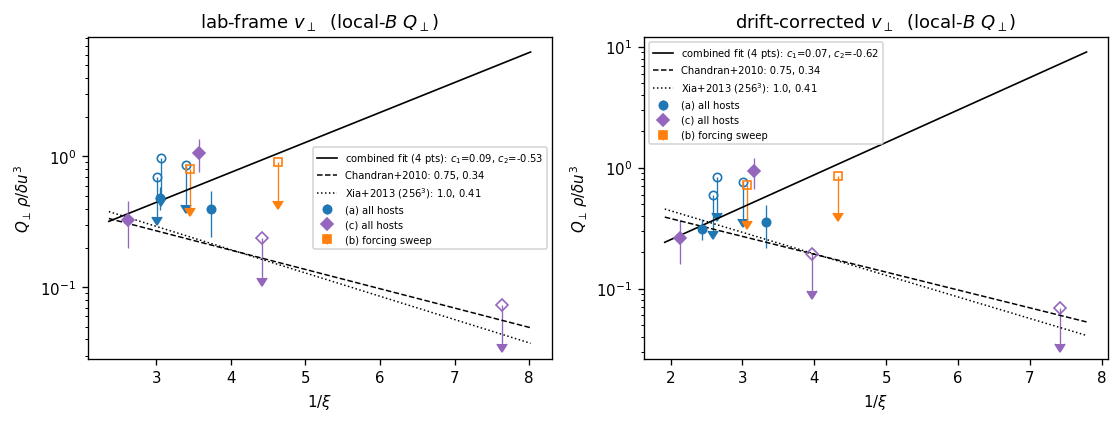

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.6))
style = [("(a) all hosts", "o", "C0"), ("(c) all hosts", "D", "C4"),
         ("(b) forcing sweep", "s", "C1")]
for name, m, c in style:
    p = sets[name]
    for j, tag in enumerate(("lab", "gyro")):
        xk, rk, dk = TAGS[tag]
        scale = p[rk]/p[dk]**3
        lim = p["Q"] <= 2*p["Qerr"]
        qup = np.maximum(p["Q"] + 2*p["Qerr"], 2*p["Qerr"])*scale
        ax[j].errorbar(1.0/p[xk][~lim], (p["Q"]*scale)[~lim], yerr=(p["Qerr"]*scale)[~lim],
                       fmt=m, color=c, ms=5, lw=0.8, label=name)
        if lim.any():
            ax[j].errorbar(1.0/p[xk][lim], qup[lim], yerr=0.5*qup[lim], uplims=True,
                           fmt=m, color=c, ms=5, mfc="none", lw=0.8)
for j, tag in enumerate(("lab", "gyro")):
    fr = fits[("(a)+(b)+(c) combined", tag)]
    allx = 1.0/np.concatenate([sets[n][TAGS[tag][0]] for n, _m, _c in style])
    xs = np.linspace(0.9*np.nanmin(allx), 1.05*np.nanmax(allx), 50)
    if fr is not None:
        ax[j].plot(xs, fr["c1"]*np.exp(-fr["c2"]*xs), "k-", lw=1.0,
                   label=f"combined fit ({fr['n']} pts): $c_1$={fr['c1']:.2f}, "
                         f"$c_2$={fr['c2']:.2f}")
    ax[j].plot(xs, 0.75*np.exp(-0.34*xs), "k--", lw=0.9, label="Chandran+2010: 0.75, 0.34")
    ax[j].plot(xs, 1.0*np.exp(-0.41*xs), "k:", lw=0.9, label="Xia+2013 ($256^3$): 1.0, 0.41")
    ax[j].set_yscale("log"); ax[j].set_xlabel(r"$1/\xi$")
    ax[j].set_ylabel(r"$Q_\perp\,\rho/\delta u^3$")
    ax[j].set_title(("lab-frame " if tag == "lab" else "drift-corrected ") + r"$v_\perp$"
                    + r"  (local-$B$ $Q_\perp$)")
    ax[j].legend(fontsize=6)
plt.tight_layout(); plt.show()

### Reading the fit

> **AWAITING PRODUCTION DATA.** The numbers printed above come from whatever profile this
> notebook was run under. Under `smoke` or `mvp` the turbulence has essentially no inertial
> range, the windows hold few gyroperiods, and the fit is a *machinery check* — that
> `chandran_fit` returns finite numbers on real sidecar data, that the limit rule fires, that
> the plot draws. The interpretation below is the template the production (`full`) run fills
> in; do not quote a $c_2$ from a non-`full` profile.

What to read, in order, when the production numbers land:

1. **Is there an exponential at all?** The combined fit's $c_2$ with its fit error, and
   $R^2(\mathrm{norm})$ — the fit's own score, on $\log(Q_\perp\rho/\delta u^3)$, with the
   $\delta u^3/\rho$ scaling already divided out, so it scores only the exponential factor.
   $R^2(\log Q)$ credits the prefactor as well and is the number the power-law comparison uses.
   A **null** here looks like $c_2$ within $1\sigma$ of zero over a $\xi$ lever of $\ge3$,
   with the measured $Q_\perp$ everywhere well above the E = 0 control's floor. That is a
   result, not a failure — but only if the lever and the floor are both shown.
2. **Where does it sit against the literature?** Xia et al.'s $c_2$ falls monotonically with
   Reynolds number: $0.44$ at $Re = 2400$, $0.41$ at $6000$, $0.29$ at $15000$, $0.20$–$0.25$
   at $38000$. The production run's $Re$ is printed in the configuration cell, so the
   comparison is to the row at *that* $Re$, not to their headline $0.21$. Their $c_1$ rises
   from $\sim0.7$ at $\beta_i = 0.006$ to $\sim3.6$ at $\beta_i = 1$; the $\beta_i$ column in
   the ensemble table says which of their rows this run's cohorts resemble.
3. **How much of it is protocol?** The sensitivity table. The Xia-comparable row (every point,
   no limit rule) is the like-for-like comparison with the published numbers — in 2D that row
   moved $c_2$ by $+0.2$, which is larger than the difference between Xia's coarsest and
   finest runs. Quote both, and never a $c_2$ without saying which rule and which frame
   produced it.
4. **How does it compare with 2D?** The 2D campaign, same protocol, $\varepsilon = 0.1$,
   `hyper=3`: $c_2 = 0.40\pm0.13$ (lab $v_\perp$, local-$\mathbf B$ $Q_\perp$, $2\sigma$
   rule). Three things differ between that and this run — dimensionality, the dissipation
   model (`hyper=3` there, Laplacian here) and the amplitude — and only the first is the
   question. The `hyper=3` twin in the `full` profile is what separates the second; the
   matched 2D twin below separates the third.

## Headline 2 — the parallel channel, and what 2D could not do

In 2D, $z$ is ignorable and $p_z = v_z - (q/m)\psi$ is an **exact** invariant of the
full-$\partial\psi/\partial t$ dynamics: $m\,dv_z/dt = q(E_z + (v\times B)_z)$ collapses to
$-q\,dA_z/dt$ along the orbit, so parallel energization is bounded by $(q/m)\Delta\psi$ and
cannot be secular. The 2D campaign measured that invariant holding to $0.5\%$ of its
$(q/m)\psi_{rms}$ scale over 30 time units.

In 3D the argument fails at both steps: $E_z = -\partial_z\Phi - \partial_tA_z$ keeps its
$\partial_z\Phi$ term, and $(v\times B)_z = -v_\perp\cdot\nabla_\perp A_z$ no longer accounts
for the whole force. Nothing bounds $\Delta v_z$. Three measurements ask what that buys:

1. **The invariant itself.** $p_z = v_z - (q/m)\psi$ for the full-mask ensemble, in 3D and in
   the matched 2D twin, both normalized by $(q/m)\psi_{rms}$. The 2D residual is pure
   discretization error; the 3D drift is physics, and their ratio is the cleanest statement
   this campaign can make.
2. **Secular or bounded?** $\tfrac12\langle v_{\parallel B}^2\rangle$ against time, 3D vs 2D
   twin, on a common eddy-time axis. A bounded 2D curve beside a linearly growing 3D one is
   the headline; two bounded curves say the constraint was never what suppressed the parallel
   channel.
3. **How big is it anyway?** $Q_\parallel/Q_\perp$ and $w_{E_z}/w_{tot}$ against $\beta_i$.
   Xia et al. find $Q_\parallel\ll Q_\perp$ at $\beta_i\ll1$, rising with $\beta_i$, and
   $Q_\parallel > Q_\perp$ possible at $\beta\sim1$ and $\xi\lesssim0.1$ — because in ideal
   RMHD $\delta|B|/B_0$ is second order and there is no parallel electric field, so
   Landau/transit-time damping is weak and only resonance broadening feeds the parallel
   channel. In code units $E_z/E_\perp \sim \varepsilon$, so the parallel channel is expected
   to be *amplitude*-suppressed in 3D exactly as it is in 2D. If it is, then the 2D $p_z$
   bound was never the binding constraint, which is itself worth recording.

The **matched 2D twin** makes this a comparison rather than a recollection. The 2D solver has
no Alfvén term, so $B_0$ is free there and the mapping is exact: $B_0 = 1/\varepsilon$,
$q/m = \Omega_{3D}$, $v_{th,2D} = v_{th,3D}/\varepsilon$, $u_{rms,2D} = 1$,
$t_{2D} = \varepsilon\,t_{3D}$, $\nu_{2D} = \nu_{3D}/\varepsilon$ — leaving $\Omega$, $\rho$,
$\xi$ and $\beta_i$ identical. What is *not* matched is the turbulence itself: 2D RMHD
inverse-cascades $\langle\psi^2\rangle$ to the box scale and 3D does not, so $b_{rms}/u_{rms}$
differs between the twins and the comparison is at matched $\xi$, not at matched forcing.

In [14]:
TWIN = C["twins"][0]
params_2d, path_2d, labels_2d, idx_2d = R.particle_run("twin2d", TWIN, dims=2)
kg2 = jr.setup_kgrids(params_2d)
steps_2d, ts_2d = snap_index(path_2d, params_2d)
mom_2d = dpart.read_moments(path_2d)
params_3d, path_3d, labels_3d, idx_3d = R.particle_run("a", TWIN)
kg3 = jr.setup_kgrids(params_3d)
steps_3d, ts_3d = snap_index(path_3d, params_3d)
mom_3d = dpart.read_moments(path_3d)

def pz(pstate, state, params):
    psi = grids.ifft(state.fields[1], params)[None]
    return np.stack([np.asarray(pstate.v[e][:, 2]
                                - ens["qm"]*interp.gather(psi, pstate.x[e], params)[:, 0])
                     for e, ens in enumerate(params.particles["ensembles"])])

def psi_rms(state, params):
    return float(np.sqrt(np.mean(np.asarray(grids.ifft(state.fields[1], params))**2)))

print(f"{'run':>6} {'ensemble':<20} {'rms |dp_z|':>12} {'(q/m) psi_rms':>14} "
      f"{'ratio':>8} {'rms dv_z':>10}")
pzrow = {}
for tag, params, path, steps, idx in (("3D", params_3d, path_3d, steps_3d, idx_3d),
                                      ("2D", params_2d, path_2d, steps_2d, idx_2d)):
    s0, s1 = load_state(path, steps[0], params), load_state(path, steps[-1], params)
    q0, q1 = sn.load_particles(steps[0], path, params), sn.load_particles(steps[-1], path,
                                                                         params)
    a, b = pz(q0, s0, params), pz(q1, s1, params)
    prms = psi_rms(s0, params)
    for name, e in (("full dpsi/dt", idx["full"]), ("ideal (projected)", idx["ideal_ref"])):
        qm = params.particles["ensembles"][e]["qm"]
        d = float(np.sqrt(np.mean((b[e] - a[e])**2)))
        dv = float(np.sqrt(np.mean((np.asarray(q1.v[e][:, 2])
                                    - np.asarray(q0.v[e][:, 2]))**2)))
        pzrow[(tag, name)] = d/(qm*prms)
        print(f"{tag:>6} {name:<20} {d:12.5f} {qm*prms:14.5f} {d/(qm*prms):8.3f} {dv:10.5f}")
r3, r2 = pzrow[("3D", "full dpsi/dt")], pzrow[("2D", "full dpsi/dt")]
print(f"\nthe full-mask ensemble's p_z drift is {r2:.3f} of its scale in 2D (pure "
      f"discretization error: fields frozen across a step, trilinear gather) and {r3:.3f} in "
      f"3D, a factor {r3/max(r2, 1e-12):.1f}. In 2D that number is an ERROR; in 3D it is the "
      f"parallel energization the 2D invariant forbids.")

   run ensemble               rms |dp_z|  (q/m) psi_rms    ratio   rms dv_z
    3D full dpsi/dt              0.17926        0.10848    1.653    0.19860
    3D ideal (projected)         0.20324        0.10848    1.874    0.20369
    2D full dpsi/dt              0.02193        0.50968    0.043    0.73559
    2D ideal (projected)         0.56494        0.50968    1.108    0.74298

the full-mask ensemble's p_z drift is 0.043 of its scale in 2D (pure discretization error: fields frozen across a step, trilinear gather) and 1.653 in 3D, a factor 38.4. In 2D that number is an ERROR; in 3D it is the parallel energization the 2D invariant forbids.


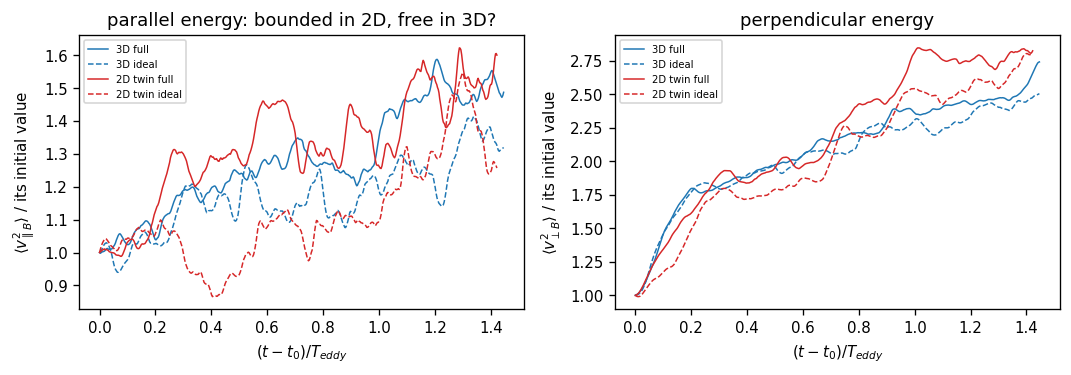

     run    d<v_parB^2>/initial   d<v_perpB^2>/initial
      3D                 0.4868                 1.7396
 2D twin                 0.5998                 1.8223

(full-mask ensemble, i.e. the one whose E_z is exactly dpsi/dt, so the 2D curve is the one the invariant applies to.)


In [15]:
# secular vs bounded: the local-B parallel energy on a common eddy-time axis. The 2D twin's
# code time is eps * the 3D time, so both are plotted against t/T_eddy.
te3 = R.LX/max(achieved.get(TWIN, (TWIN, TWIN))[0], 1e-9)
te2 = R.LX*TWIN/max(achieved.get(TWIN, (TWIN, TWIN))[0], 1e-9)
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.2))
for tag, mom, idx, te, c in (("3D", mom_3d, idx_3d, te3, "C0"),
                             ("2D twin", mom_2d, idx_2d, te2, "C3")):
    x = (mom["t"] - mom["t"][0])/te
    for e, ls, nm in ((idx["full"], "-", "full"), (idx["ideal_ref"], "--", "ideal")):
        ax[0].plot(x, 0.5*mom["vparB2"][:, e]/(0.5*mom["vparB2"][0, e]), color=c, ls=ls,
                   lw=0.9, label=f"{tag} {nm}")
        ax[1].plot(x, 0.5*mom["vperpB2"][:, e]/(0.5*mom["vperpB2"][0, e]), color=c, ls=ls,
                   lw=0.9, label=f"{tag} {nm}")
ax[0].set_ylabel(r"$\langle v_{\parallel B}^2\rangle$ / its initial value")
ax[1].set_ylabel(r"$\langle v_{\perp B}^2\rangle$ / its initial value")
for a in ax:
    a.set_xlabel(r"$(t-t_0)/T_{eddy}$"); a.legend(fontsize=6)
ax[0].set_title("parallel energy: bounded in 2D, free in 3D?")
ax[1].set_title("perpendicular energy")
plt.tight_layout(); plt.show()

def growth(mom, idx, key):
    e = idx["full"]
    f = 0.5*mom[key][:, e]
    return float(f[-1]/f[0] - 1.0)
print(f"{'run':>8} {'d<v_parB^2>/initial':>22} {'d<v_perpB^2>/initial':>22}")
for tag, mom, idx in (("3D", mom_3d, idx_3d), ("2D twin", mom_2d, idx_2d)):
    print(f"{tag:>8} {growth(mom, idx, 'vparB2'):22.4f} "
          f"{growth(mom, idx, 'vperpB2'):22.4f}")
print("\n(full-mask ensemble, i.e. the one whose E_z is exactly dpsi/dt, so the 2D curve is "
      "the one the invariant applies to.)")

 run ensemble                            beta_i      xi      Q_perp       Q_par  Qpar/Qperp  w_ez/w_tot
  3D (a) rho/dx = 2, Omega = 1.08         0.180   0.328   7.752e-03   6.747e-04       0.087       0.048
  3D (a) rho/dx = 3, Omega = 0.72         0.180   0.268   2.174e-03   8.841e-04       0.407       0.072
  3D (a) rho/dx = 4, Omega = 0.54         0.180   0.294   1.708e-03   8.322e-04       0.487       0.073
  3D (a) rho/dx = 6, Omega = 0.36         0.180   0.327   1.450e-03   9.362e-04       0.646       0.023
  3D (a) rho/dx = 8, Omega = 0.27         0.180   0.333   5.411e-04  -2.271e-05      -0.042       0.014
  3D (c) ring v_perp = 0.5 v_th_rms       0.045   0.381   1.554e-03   4.718e-04       0.304       0.041
  3D (c) ring v_perp = 1 v_th_rms         0.180   0.280   6.119e-03   1.074e-03       0.176       0.016
  3D (c) ring v_perp = 2 v_th_rms         0.720   0.226   1.086e-03   1.528e-03       1.406       0.002
  3D (c) ring v_perp = 4 v_th_rms         2.880   0.131  -4.672e

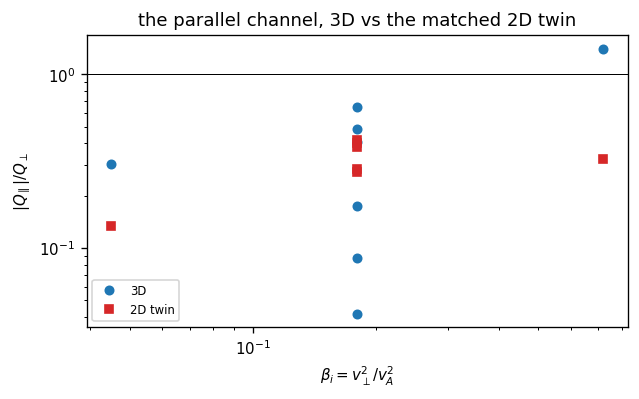

Xia et al. find Q_par << Q_perp at beta_i << 1, rising with beta_i, and Q_par > Q_perp possible at beta ~ 1 with xi <~ 0.1.


In [16]:
# Q_par/Q_perp and the work split against beta_i, 3D against the matched 2D twin
pts_3d = heating_points((params_3d, path_3d, labels_3d, idx_3d),
                        list(idx_3d["sweep"]) + list(idx_3d["rings"]))
pts_2d = heating_points((params_2d, path_2d, labels_2d, idx_2d),
                        list(idx_2d["sweep"]) + list(idx_2d["rings"]))
b3 = dpart.energy_budget(sn.load_particles(steps_3d[-1], path_3d, params_3d),
                         sn.load_particles(steps_3d[0], path_3d, params_3d))
b2 = dpart.energy_budget(sn.load_particles(steps_2d[-1], path_2d, params_2d),
                         sn.load_particles(steps_2d[0], path_2d, params_2d))
IEZ = WORK_PIECES.index("ez_ideal")

print(f"{'run':>4} {'ensemble':<34} {'beta_i':>7} {'xi':>7} {'Q_perp':>11} {'Q_par':>11} "
      f"{'Qpar/Qperp':>11} {'w_ez/w_tot':>11}")
for tag, p, bud_, in (("3D", pts_3d, b3), ("2D", pts_2d, b2)):
    for j in range(len(p["e"])):
        e = int(p["e"][j])
        wtot = bud_["total_work"][e]
        print(f"{tag:>4} {p['label'][j]:<34} {p['beta'][j]:7.3f} {p['xi'][j]:7.3f} "
              f"{p['Q'][j]:11.3e} {p['Qpar'][j]:11.3e} "
              f"{p['Qpar'][j]/p['Q'][j]:11.3f} "
              f"{(bud_['work'][e][IEZ]/wtot if wtot else np.nan):11.3f}")

fig, ax = plt.subplots(figsize=(5.4, 3.4))
for tag, p, m, c in (("3D", pts_3d, "o", "C0"), ("2D twin", pts_2d, "s", "C3")):
    ok = p["Q"] > 0
    ax.loglog(p["beta"][ok], np.abs(p["Qpar"][ok]/p["Q"][ok]), m, color=c, ms=5, label=tag)
ax.axhline(1.0, color="k", lw=0.6)
ax.set_xlabel(r"$\beta_i = v_\perp^2/v_A^2$"); ax.set_ylabel(r"$|Q_\parallel|/Q_\perp$")
ax.set_title(r"the parallel channel, 3D vs the matched 2D twin")
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
print("Xia et al. find Q_par << Q_perp at beta_i << 1, rising with beta_i, and Q_par > "
      "Q_perp possible at beta ~ 1 with xi <~ 0.1.")

### Reading the parallel channel

> **AWAITING PRODUCTION DATA** — as above, the numbers printed by the three cells above are a
> pipeline check under any profile but `full`.

The three things to read, and what a null looks like for each:

- **The $p_z$ ratio.** In 2D the full-mask drift is a discretization error and was $0.5\%$ of
  $(q/m)\psi_{rms}$ over 30 time units; whatever the 2D twin here reproduces is the error
  floor for this pipeline. If the 3D drift is not several times that floor, the freed
  constraint is not being exercised, and the honest statement is a bound rather than a
  measurement — check first that particles actually traverse the box in $z$ (at
  $v_\parallel\sim v_{th}$ and run length $T$, the parallel excursion is $v_{th}T$ against
  $L_z$, both printed in the configuration cells).
- **Secular vs bounded.** Any growth in $\langle v_{\parallel B}^2\rangle$ must be compared
  with the E = 0 control and with the $\delta b = 0$ control, both of which sit in the same
  run and neither of which can heat. A 2D curve that saturates while the 3D one grows
  linearly is the clean result. **Two saturating curves is also a result**: it says the 2D
  invariant was never the binding constraint and that parallel energization is suppressed by
  the amplitude ($E_z/E_\perp\sim\varepsilon$ in code units), which is what the 2D campaign
  already concluded from the $B_0$ twins.
- **$Q_\parallel/Q_\perp$ against $\beta_i$.** This is directly comparable to Xia et al.'s
  Fig. 7, with the caveat that $\beta_i$ and $\xi$ are locked here. A rise with $\beta_i$
  reproduces them; a flat curve does not, and the locking is the first thing to blame.

Attribution, stated once so it is not re-litigated: a disagreement with Xia et al. can come
from (i) **the protocol** — the limit rule, the window, the frame, the $\delta u$ convention,
all of which the sensitivity table prices; (ii) **the turbulence** — Reynolds number,
dissipation model, box aspect, $\chi$, all printed in the base-turbulence cells and all
different from the 2D campaign as well; or (iii) **dimensionality**, which is the only one of
the three this notebook exists to measure, and which is only isolable because the 2D twin and
the `hyper=3` twin hold the other two fixed one at a time.

## What this does and does not show

**Does show** (once run under the `full` profile — see the two "reading" sections):

- a $Q_\perp(\xi)$ measurement in 3D RMHD at a *measured* amplitude $\varepsilon = u_{rms}$
  and a *measured* Reynolds number, quoted both under the $2\sigma$ upper-limit rule and in
  the Xia-comparable form that admits every point, with the frame, the $\delta u$ convention
  and the design mix priced in a sensitivity table;
- the 2D-vs-3D parallel-energization comparison, against a matched 2D twin run rather than a
  remembered number: the $p_z$ drift, the secular-vs-bounded parallel energy, and
  $Q_\parallel/Q_\perp$ against $\beta_i$;
- that the machinery is exact where it claims to be: the per-piece work accumulators close
  against $\tfrac12|v|^2$ to round-off, a piece an ensemble's mask omits is bitwise zero, and
  both controls conserve $|v|^2$ per particle at the numerical floor.

**Does not show.**

- **$\beta_i$ independent of $\xi$.** $B_0$ is pinned to 1 in 3D, so the per-ensemble
  amplitude rescaling Xia et al. use to put several $\beta_i$ cohorts on one run is
  unavailable and $\beta_i = (\delta u/\xi)^2$ is fixed once $\xi$ is. Every $\beta_i$
  statement here is entangled with $\xi$.
- **An amplitude scan at fixed turbulence.** In 2D, $B_0$ made $\varepsilon$ a per-ensemble
  knob and the $\varepsilon = 1$ vs $0.1$ twins rode identical fields. In 3D an amplitude
  contrast is a different *run*, so the fields differ too.
- **A converged inertial range**, unless the printed spectra say otherwise: the fitted
  $\delta u$ exponent inherits whatever the dissipation does, and the `full` profile's
  Reynolds number is Xia et al.'s *second-coarsest*, not their finest.
- **Anything about non-ideal $E_z$ as physics.** With Laplacian dissipation the resistive
  piece is $\eta j_z$ rather than a hyper-resistive regularization, but $\eta$ in RMHD is
  still a fluid closure, not the kinetic physics that supports reconnection $E_\parallel$; the
  full-mask ensemble exists here for the $\partial\psi/\partial t$-exactness check and for the
  $p_z$ comparison, not as a reconnection measurement.
- **Multi-rank 3D.** Particles are single-process only (`plans/TESTPART_PLAN.md` §4); the
  resolution ceiling of this campaign is one device's memory and one device's speed.